## In this competition, you’re challenged to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t. You’ll have access to a dataset of 10,000 tweets that were hand classified. 

In [139]:
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ragec\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ragec\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sub = pd.read_csv('data/sample_submission.csv')

In [30]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

## EDA

In [4]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [61]:
#Sample text
train.text[0]

'Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all'

In [10]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [7]:
train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [9]:
train.shape, test.shape

((7613, 5), (3263, 4))

In [11]:
#drop duplicates
train.drop_duplicates(subset = ['text', 'target'], keep = 'first', inplace = True)
train.shape

(7521, 5)

In [25]:
train['target'].value_counts()

0    4315
1    3206
Name: target, dtype: int64

#### Class imbalance check

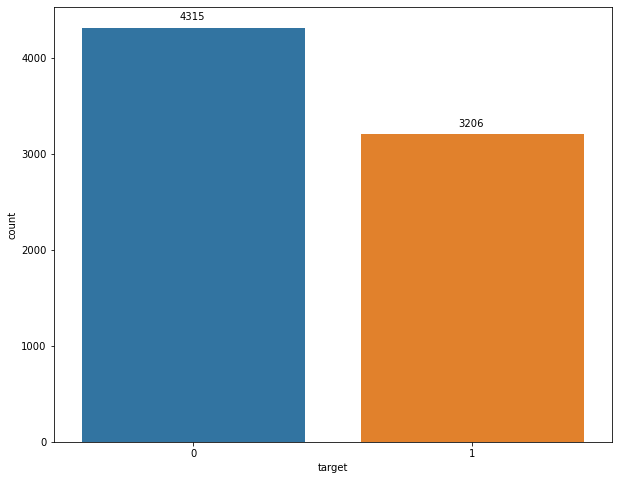

In [24]:
plt.figure(figsize=(10,8))
ax = sns.countplot(train['target'])
#annotate
for p in ax.patches:
        ax.annotate( p.get_height(), (p.get_x() + 0.35, p.get_height() + 80))

In [28]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7604,10863,NaN,NaN,#WorldNews Fallen powerlines on G:link tram: U...,1
7605,10864,NaN,NaN,on the flip side I'm at Walmart and there is a...,1
7606,10866,NaN,NaN,Suicide bomber kills 15 in Saudi security site...,1
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1


In [31]:
# Check twit lenghts of 1 and 0
train['twit_len'] = train['text'].apply(lambda x: len(x.split()))

In [32]:
train

,id,keyword,location,text,target,twit_len
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,13
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,7
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,22
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,8
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,16
...,...,...,...,...,...,...
7604,10863,NaN,NaN,#WorldNews Fallen powerlines on G:link tram: U...,1,19
7605,10864,NaN,NaN,on the flip side I'm at Walmart and there is a...,1,26
7606,10866,NaN,NaN,Suicide bomber kills 15 in Saudi security site...,1,20
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1,11


In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7521 entries, 0 to 7612
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7521 non-null   int64 
 1   keyword   7465 non-null   object
 2   location  5031 non-null   object
 3   text      7521 non-null   object
 4   target    7521 non-null   int64 
 5   twit_len  7521 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 731.3+ KB


In [57]:
#min - 1, max - 31
train[train.target== 0].twit_len.describe()

count    7521.000000
mean       14.880202
std         5.736606
min         1.000000
25%        11.000000
50%        15.000000
75%        19.000000
max        31.000000
Name: twit_len, dtype: float64

In [58]:
#not disaster
train[train.target== 0].twit_len.describe()

count    4315.000000
mean       14.680185
std         6.161718
min         1.000000
25%        10.000000
50%        15.000000
75%        19.000000
max        31.000000
Name: twit_len, dtype: float64

In [59]:
#for disaster
#mean lenght is greater
train[train.target== 1].twit_len.describe()

count    3206.000000
mean       15.149407
std         5.097472
min         2.000000
25%        11.000000
50%        15.000000
75%        19.000000
max        30.000000
Name: twit_len, dtype: float64

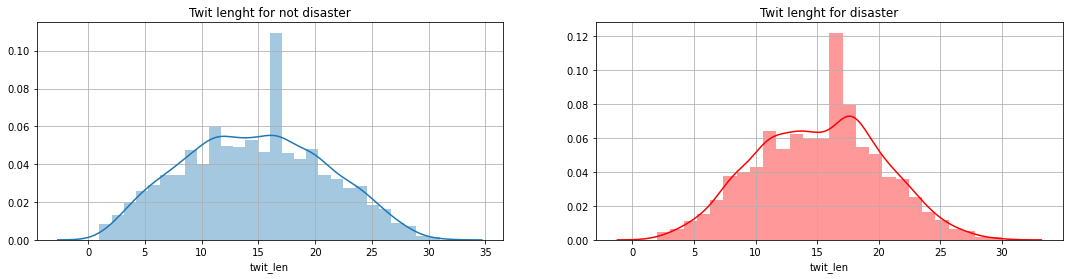

In [55]:
# Не было замечено существенной разницы в кол-ве символов, но для твитов о катастрофе, плотность распределения в промежутке 15-20 выше
plt.subplot(1, 2, 1)
sns.distplot(train[train.target== 0].twit_len)
plt.title('Twit lenght for not disaster')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.distplot(train[train.target== 1].twit_len, color = 'red')
plt.title('Twit lenght for disaster')
plt.grid(True)
plt.subplots_adjust(right = 2.5)
plt.show()

## Bag-of-words

In [82]:
corpus = train[train.target == 1].text.apply(lambda x: [word.lower() for word in x.split()])

In [115]:
len(corpus)

3206

In [84]:
#Наиболее часто встречающиеся слова
from collections import Counter
cnt = Counter()
for x in corpus:
    cnt.update(x)
print(cnt.most_common(50))

[('the', 1305), ('in', 1123), ('of', 891), ('a', 881), ('to', 746), ('and', 487), ('on', 400), ('-', 383), ('for', 380), ('is', 340), ('at', 297), ('i', 283), ('by', 272), ('from', 234), ('that', 178), ('this', 176), ('after', 173), ('as', 165), ('was', 164), ('with', 163), ('are', 161), ('it', 160), ('fire', 148), ('have', 139), ('my', 130), ('you', 120), ('more', 120), ('via', 115), ('up', 111), ('be', 110), ('over', 109), ('&amp;', 104), ('an', 103), ('...', 99), ('suicide', 98), ('no', 96), ('who', 95), ('but', 95), ('has', 94), ('people', 93), ('police', 93), ('killed', 92), ('when', 92), ('disaster', 92), ('like', 90), ('not', 88), ('california', 87), ('than', 84), ('just', 83), ('been', 81)]


### Data cleansing

In [112]:
#Data cleansing 
from nltk.stem import WordNetLemmatizer 
nltk.download('wordnet')
import re
import string
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text= text.lower()
    #remove digits
    text= re.sub('[0-9]', '', text)
    #remove punctuation
    text  = "".join([char for char in text if char not in string.punctuation])
    #tokenizing
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    #remove stopwords
    tokens=[word for word in tokens if word not in stopwords.words('english')]
    text = ' '.join(tokens)
    return text

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ragec\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\wordnet.zip.


In [114]:
train['cleaned'] = train.text.apply(lambda x: clean_text(x))
test['cleaned'] = test.text.apply(lambda x: clean_text(x))

In [116]:
#Как минимум меньше артиклей 
corpus_cl = train[train.target == 1].cleaned.apply(lambda x: [word.lower() for word in x.split()])
#Cleaned bag-of-words
from collections import Counter
cnt_cl = Counter()
for x in corpus_cl:
    cnt_cl.update(x)
print(cnt_cl.most_common(50))

[('fire', 256), ('wa', 173), ('news', 139), ('via', 119), ('california', 114), ('disaster', 113), ('u', 107), ('police', 106), ('amp', 106), ('people', 104), ('suicide', 104), ('family', 102), ('home', 98), ('ha', 95), ('killed', 93), ('train', 92), ('like', 91), ('storm', 91), ('crash', 89), ('hiroshima', 89), ('building', 88), ('pm', 87), ('year', 85), ('bomb', 85), ('wildfire', 80), ('flood', 79), ('emergency', 76), ('attack', 76), ('bombing', 73), ('car', 72), ('get', 70), ('accident', 70), ('nuclear', 70), ('mh', 70), ('two', 69), ('one', 69), ('video', 69), ('time', 68), ('say', 66), ('death', 65), ('dead', 63), ('northern', 61), ('legionnaire', 60), ('burning', 59), ('war', 59), ('im', 56), ('still', 56), ('bomber', 56), ('new', 55), ('atomic', 55)]


## TF IDF

In [125]:
# Понижаем значимость наиболее часто встречаемых слов
tfidf = TfidfVectorizer(sublinear_tf=True,max_features=60000, min_df=1, norm='l2',  ngram_range=(1,2))
features_train = tfidf.fit_transform(train.cleaned).toarray()
features_train.shape

(7521, 60000)

In [126]:
features_test = tfidf.transform(test.cleaned).toarray()

## ML

In [135]:
k_fold = StratifiedKFold(n_splits=4, random_state=48, shuffle=True)
accuracy = []
n = 1
y = train['target']

In [140]:
for train_idx, test_idx in k_fold.split(features_train, y):
    X_tr, X_val = features_train[train_idx], features_train[test_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[test_idx]
    model = LogisticRegression(max_iter=1000, C=3)
    model.fit(X_tr,y_tr)
    s = model.predict(X_val)
    sub[str(n)] = model.predict(features_test) 
    accuracy.append(accuracy_score(y_val, s))
    print(accuracy[n-1])
    n+=1

0.786815523657629
0.7957446808510639
0.7978723404255319
0.7925531914893617


## Evaluation

In [141]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_val)
print(classification_report(y_pred, y_val ))

              precision    recall  f1-score   support

           0       0.76      0.92      0.84      1079
           1       0.86      0.62      0.72       801

    accuracy                           0.79      1880
   macro avg       0.81      0.77      0.78      1880
weighted avg       0.80      0.79      0.79      1880



In [149]:
#Выбрать популярный прогноз
sub_final = sub[['1', '2', '3' , '4']].mode(axis = 1)[0].values
sub['target'] = sub_final
sub = sub[['id', 'target']]
sub['target'] = sub['target'].apply(lambda x: int(x))

<ipython-input-149-1c45a3e3cb9c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['target'] = sub['target'].apply(lambda x: int(x))


In [151]:
sub.to_csv('data/submission.csv', index = False)